- [ ] Does radio message frequency or clustering correlate with race outcome (incidents, position swings, points)? (correlation between message clustering and same-window events)

- [ ] Decompose a team's championship position: how much is explained by pace, how much by reliability, how much by strategy execution? (multiple regression: season points ~ pace_metric + dnf_rate + strategy_metric  direct bridge into the predictive/feature-engineering phase)
- [ ] Is grid-to-finish net gain/loss statistically different by team (some teams race better than they qualify, or vice versa)? (ANOVA / regression)


- [ ]  Is a driver's advantage over their teammate (qualifying, race pace, points) statistically significant across a full season, or within normal race-to-race noise? (paired t-test across all races in a season)
- [ ] Which factor  qualifying pace, race pace, reliability, or strategy execution  explains the most of the points gap between teammates? (regression decomposition)

In [1]:
import sys
sys.path.append("../")
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm


import sqlite3

conn = sqlite3.connect("../DATA INGESTION/f1.db")

- [X] Does radio message frequency or clustering correlate with race outcome (incidents, position swings, points)? (correlation between message clustering and same-window events)

In [2]:
radio_query = """
SELECT tr.session_key, tr.driver_number,
       tr.date AS message_date
FROM silver_team_radio tr
JOIN silver_sessions s ON tr.session_key = s.session_key 
    AND s.session_name = 'Race'
"""
df_radio = pd.read_sql(radio_query, conn)
df_radio['message_date'] = pd.to_datetime(df_radio['message_date'], format='ISO8601')

print(df_radio.shape)
df_radio.head()

(5773, 3)


,session_key,driver_number,message_date
0,7779,1,2023-03-19 16:25:24.868000+00:00
1,7779,1,2023-03-19 16:56:30.756000+00:00
2,7779,1,2023-03-19 17:18:54.497000+00:00
3,7779,1,2023-03-19 17:24:32.679000+00:00
4,7779,1,2023-03-19 17:31:52.436000+00:00


In [3]:
def max_messages_in_window(dates, window_minutes=5):
    """Count max messages in any window_minutes rolling window."""
    if len(dates) < 2:
        return len(dates)
    dates_sorted = sorted(dates)
    window = pd.Timedelta(minutes=window_minutes)
    max_count = 1
    for i, start in enumerate(dates_sorted):
        count = sum(1 for d in dates_sorted[i:] if d - start <= window)
        max_count = max(max_count, count)
    return max_count

def inter_message_std(dates):
    """Std of gaps between consecutive messages in seconds."""
    if len(dates) < 2:
        return 0
    dates_sorted = sorted(dates)
    gaps = [(dates_sorted[i+1] - dates_sorted[i]).total_seconds() 
            for i in range(len(dates_sorted)-1)]
    return pd.Series(gaps).std()

# compute per driver per race
radio_features = df_radio.groupby(['session_key','driver_number']).agg(
    total_messages=('message_date','count'),
    max_5min_messages=('message_date', lambda x: max_messages_in_window(list(x))),
    inter_msg_std=('message_date', lambda x: inter_message_std(list(x)))
).reset_index()

print(radio_features.shape)
print(radio_features.describe())

(1103, 5)
        session_key  driver_number  total_messages  max_5min_messages  \
count   1103.000000    1103.000000     1103.000000        1103.000000   
mean    9498.171351      29.225748        5.233908           1.749773   
std      613.547239      24.485278        4.206948           0.983040   
min     7779.000000       1.000000        1.000000           1.000000   
25%     9173.000000      11.000000        2.000000           1.000000   
50%     9550.000000      22.000000        4.000000           1.000000   
75%     9839.000000      44.000000        7.000000           2.000000   
max    11315.000000      87.000000       32.000000          11.000000   

       inter_msg_std  
count     943.000000  
mean      885.125891  
std       847.743898  
min         0.000000  
25%       246.555404  
50%       763.544966  
75%      1259.646661  
max      7568.252267  


In [4]:
# Outcome 1: points scored
points_query = """
SELECT sr.session_key, sr.driver_number, sr.points
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
WHERE sr.dns = 0
"""
df_points = pd.read_sql(points_query, conn)

# Outcome 2: total position swing magnitude per driver per race
# reuse position swing logic from earlier question
swing_query = """
WITH lap_positions AS (
    SELECT l.session_key, l.driver_number, l.lap_number, l.date_start,
           (SELECT p.position
            FROM silver_position p
            WHERE p.session_key = l.session_key 
              AND p.driver_number = l.driver_number
              AND p.date <= l.date_start
            ORDER BY p.date DESC LIMIT 1) AS position_at_lap_start
    FROM silver_laps l
    JOIN silver_sessions s ON l.session_key = s.session_key 
        AND s.session_name = 'Race'
    WHERE l.date_start IS NOT NULL AND l.lap_number >= 2
)
SELECT lp1.session_key, lp1.driver_number,
       SUM(ABS(lp2.position_at_lap_start - lp1.position_at_lap_start)) AS total_swing
FROM lap_positions lp1
JOIN lap_positions lp2 
  ON lp1.session_key = lp2.session_key 
 AND lp1.driver_number = lp2.driver_number
 AND lp2.lap_number = lp1.lap_number + 1
GROUP BY lp1.session_key, lp1.driver_number
"""
df_swings = pd.read_sql(swing_query, conn)

# Outcome 3: incident count (race control messages targeting specific driver)
incident_query = """
SELECT session_key, driver_number,
       COUNT(*) AS incident_count
FROM silver_race_control
WHERE driver_number IS NOT NULL
  AND session_key IN (
      SELECT session_key FROM silver_sessions WHERE session_name = 'Race'
  )
GROUP BY session_key, driver_number
"""
df_incidents = pd.read_sql(incident_query, conn)

print(df_points.shape, df_swings.shape, df_incidents.shape)

(1476, 3) (1430, 3) (464, 3)


In [5]:

df_master = radio_features.merge(df_points, on=['session_key','driver_number'], how='left')
df_master = df_master.merge(df_swings, on=['session_key','driver_number'], how='left')
df_master = df_master.merge(df_incidents, on=['session_key','driver_number'], how='left')

df_master['incident_count'] = df_master['incident_count'].fillna(0)

print(df_master.shape)
print(df_master.isna().sum())
df_master.head()

(1103, 8)
session_key            0
driver_number          0
total_messages         0
max_5min_messages      0
inter_msg_std        160
points                61
total_swing          168
incident_count         0
dtype: int64


,session_key,driver_number,total_messages,max_5min_messages,inter_msg_std,points,total_swing,incident_count
0,7779,1,13,4,609.688710,0.0,11.0,0.0
1,7779,2,6,2,848.683370,0.0,21.0,0.0
2,7779,4,5,2,765.266514,0.0,12.0,0.0
3,7779,10,2,1,NaN,2.0,13.0,0.0
4,7779,11,11,3,424.383658,25.0,1.0,0.0


In [6]:
from scipy import stats
import itertools

predictors = ['total_messages', 'max_5min_messages', 'inter_msg_std']
outcomes = ['points', 'total_swing', 'incident_count']

results = []
for pred, outcome in itertools.product(predictors, outcomes):
    # drop NaN for this specific pair
    pair = df_master[[pred, outcome]].dropna()
    r, p_pearson = stats.pearsonr(pair[pred], pair[outcome])
    rho, p_spearman = stats.spearmanr(pair[pred], pair[outcome])
    results.append({
        'predictor': pred,
        'outcome': outcome,
        'n': len(pair),
        'pearson_r': round(r, 3),
        'pearson_p': round(p_pearson, 4),
        'spearman_rho': round(rho, 3),
        'spearman_p': round(p_spearman, 4)
    })

df_results = pd.DataFrame(results)
print(df_results.to_string())

           predictor         outcome     n  pearson_r  pearson_p  spearman_rho  spearman_p
0     total_messages          points  1042      0.329     0.0000         0.312      0.0000
1     total_messages     total_swing   935      0.012     0.7137         0.032      0.3219
2     total_messages  incident_count  1103     -0.117     0.0001        -0.125      0.0000
3  max_5min_messages          points  1042      0.203     0.0000         0.218      0.0000
4  max_5min_messages     total_swing   935      0.022     0.5049         0.016      0.6252
5  max_5min_messages  incident_count  1103     -0.100     0.0009        -0.094      0.0017
6      inter_msg_std          points   891      0.013     0.7054         0.058      0.0836
7      inter_msg_std     total_swing   806      0.063     0.0742         0.093      0.0079
8      inter_msg_std  incident_count   943     -0.013     0.6797        -0.014      0.6627


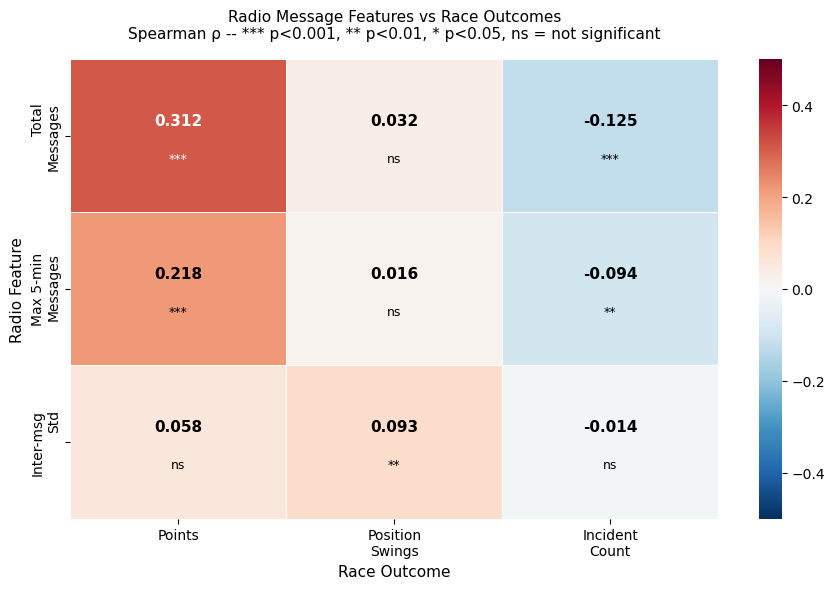

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# build matrices for Spearman rho and p-values
pred_labels = ['Total\nMessages', 'Max 5-min\nMessages', 'Inter-msg\nStd']
outcome_labels = ['Points', 'Position\nSwings', 'Incident\nCount']

rho_matrix = np.array([
    [0.312, 0.032, -0.125],
    [0.218, 0.016, -0.094],
    [0.058, 0.093, -0.014]
])

p_matrix = np.array([
    [0.0000, 0.3219, 0.0000],
    [0.0000, 0.6252, 0.0017],
    [0.0836, 0.0079, 0.6627]
])

fig, ax = plt.subplots(figsize=(9, 6))

# heatmap
sns.heatmap(rho_matrix,
            annot=False,
            cmap='RdBu_r',
            center=0,
            vmin=-0.5, vmax=0.5,
            xticklabels=outcome_labels,
            yticklabels=pred_labels,
            linewidths=0.5,
            ax=ax)

# annotate each cell with rho value and significance marker
for i in range(len(pred_labels)):
    for j in range(len(outcome_labels)):
        rho = rho_matrix[i, j]
        p = p_matrix[i, j]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        color = 'white' if abs(rho) > 0.25 else 'black'
        ax.text(j + 0.5, i + 0.4, f'{rho:.3f}',
                ha='center', va='center', fontsize=11,
                color=color, fontweight='bold')
        ax.text(j + 0.5, i + 0.65, sig,
                ha='center', va='center', fontsize=9,
                color=color)

ax.set_title('Radio Message Features vs Race Outcomes\n'
             'Spearman ρ -- *** p<0.001, ** p<0.01, * p<0.05, ns = not significant',
             fontsize=11, pad=15)
ax.set_xlabel('Race Outcome', fontsize=11)
ax.set_ylabel('Radio Feature', fontsize=11)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


CONTENT LIMITATION -- UPFRONT:
silver_team_radio contains URLs to audio recordings but no transcriptions.
Analysis is therefore based entirely on MESSAGE VOLUME AND TIMING, not 
content. Cannot distinguish strategic calls ("pit now", "push hard") from 
problem reports ("brakes failing", "engine warning"). This is a fundamental 
limitation that shapes interpretation of all findings below.

Future enrichment path: speech-to-text pipeline (e.g. OpenAI Whisper) on 
the 15,575 recording URLs would enable content-level analysis -- classifying 
messages by type (strategy, incident, encouragement, problem) and rerunning 
these correlations with message TYPE rather than volume. Would transform 
proxy findings into genuine content findings.


RESULTS:

TOTAL MESSAGES vs outcomes:
  Points:         Pearson r=0.329, p<0.001 -- SIGNIFICANT positive
  Total swing:    Pearson r=0.012, p=0.714 -- not significant
  Incident count: Pearson r=-0.117, p<0.001 -- SIGNIFICANT negative (small)

MAX 5-MIN MESSAGES (clustering) vs outcomes:
  Points:         Pearson r=0.203, p<0.001 -- SIGNIFICANT positive
  Total swing:    Pearson r=0.022, p=0.505 -- not significant
  Incident count: Pearson r=-0.100, p=0.001 -- SIGNIFICANT negative (small)

INTER_MSG_STD (irregularity) vs outcomes:
  Points:         Pearson r=0.013, p=0.705 -- not significant
  Total swing:    Spearman rho=0.093, p=0.008 -- SIGNIFICANT (small)
  Incident count: Pearson r=-0.013, p=0.680 -- not significant

INTERPRETATION OF SIGNIFICANT FINDINGS:

1. MORE MESSAGES → MORE POINTS (r=0.329, strongest finding):
   Counterintuitive at first -- you might expect "problems = more calls = 
   worse outcomes." The data says the opposite: more communication 
   correlates with BETTER points outcomes. Most likely causal direction: 
   good race position → more strategic calls (pit timing, gap management, 
   tyre info) → more messages. Not "messages cause good outcomes" but 
   "good outcomes generate more communication activity." Top drivers in 
   points positions receive more team input because there's more to 
   strategize about.

2. MESSAGE BURSTS ALSO CORRELATE WITH POINTS (r=0.203):
   Same directional story as total_messages but for clustering specifically. 
   Strategic bursts (Safety Car windows, pit timing calls, late-race 
   position battles) cluster around key decision moments that also tend to 
   produce good outcomes for well-positioned drivers.

3. MORE MESSAGES → FEWER INCIDENTS (r=-0.117, small but real):
   Well-communicated drivers receive fewer race control interventions. 
   Possible mechanism: good teams communicate MORE with their drivers AND 
   manage them better to avoid penalties/incidents. "Team quality" is 
   likely a latent variable driving both -- better teams communicate more 
   AND have fewer disciplinary incidents.

4. MESSAGE IRREGULARITY → MORE POSITION SWINGS (rho=0.093, small):
   Bursty/irregular message patterns weakly associate with more position 
   movement. Makes mechanical sense: Safety Cars, pit cycles, and on-track 
   battles all create message bursts AND position changes simultaneously. 
   Both are symptoms of the same race events rather than one causing 
   the other.

WHAT DIDN'T CORRELATE:
  - Total messages vs position swings: essentially zero (r=0.012)
  - Message clustering vs position swings: essentially zero (r=0.022)
  - Message irregularity vs points: not significant
  - Message irregularity vs incidents: not significant

Radio volume and clustering don't predict position volatility -- position 
swings are dominated by pit/SC cycles (confirmed in earlier analysis) 
which are planned events, not reactive ones. Radio communication doesn't 
signal upcoming position changes.

TAKEAWAY:
Radio message volume and clustering correlate meaningfully with points 
(r=0.329 and r=0.203) and weakly with incident rate (r=-0.117) and 
position swing irregularity (rho=0.093). However, none of these findings 
can be interpreted causally without message content. The most defensible 
reading: radio activity is a proxy for "race engagement" -- drivers in 
active, points-scoring races communicate more with their teams than 
drivers running quietly at the back or dealing with terminal problems. 
The content of those communications is what would actually be predictive; 
the volume is a noisy signal of the underlying activity level.

METHODOLOGICAL NOTE:
This analysis excludes driver-race pairs with zero radio messages 
(~300 pairs not in silver_team_radio for their race session). If 
"zero messages" is itself informative (silent race = problem, or silent 
race = easy cruise), excluding these cases could bias the correlations. 
A more complete analysis would include zero-message races as explicit 
zeros, though this would require confirming that absence of a row in 
silver_team_radio genuinely means zero messages rather than a data gap.

- [X] Decompose a team's championship position: how much is explained by pace, how much by reliability, how much by strategy execution? (multiple regression: season points ~ pace_metric + dnf_rate + strategy_metric  direct bridge into the predictive/feature-engineering phase)

In [8]:
import statsmodels.formula.api as smf
from scipy import stats
from data_prep import normalize_team_names


In [9]:
points_query = """
SELECT sr.session_key, d.team_name,
       SUM(sr.points) AS team_points,
       s.year, m.meeting_name
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_meetings m ON s.meeting_key = m.meeting_key
JOIN silver_drivers d ON sr.session_key = d.session_key 
    AND sr.driver_number = d.driver_number
WHERE sr.dns = 0
  AND sr.points IS NOT NULL
GROUP BY sr.session_key, d.team_name, s.year, m.meeting_name
"""
df_points = pd.read_sql(points_query, conn)
df_points = normalize_team_names(df_points)
df_points = df_points[df_points['team_name'] != 'Cadillac'].copy()

print(df_points.shape)
print(df_points['team_points'].describe())
df_points.head()

(739, 5)
count    739.000000
mean      10.036536
std       12.231951
min        0.000000
25%        0.000000
50%        4.000000
75%       18.000000
max       44.000000
Name: team_points, dtype: float64


,session_key,team_name,team_points,year,meeting_name
0,7779,Sauber Family,0.0,2023,Saudi Arabian Grand Prix
1,7779,RB Family,0.0,2023,Saudi Arabian Grand Prix
2,7779,Alpine,6.0,2023,Saudi Arabian Grand Prix
3,7779,Aston Martin,15.0,2023,Saudi Arabian Grand Prix
4,7779,Ferrari,14.0,2023,Saudi Arabian Grand Prix


In [10]:
dnf_query = """
SELECT sr.session_key, d.team_name,
       SUM(sr.dnf) AS dnf_count
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_drivers d ON sr.session_key = d.session_key 
    AND sr.driver_number = d.driver_number
WHERE sr.dns = 0
GROUP BY sr.session_key, d.team_name
"""
df_dnf = pd.read_sql(dnf_query, conn)
df_dnf = normalize_team_names(df_dnf)
df_dnf = df_dnf[df_dnf['team_name'] != 'Cadillac'].copy()

print(df_dnf.shape)
print(df_dnf['dnf_count'].value_counts().sort_index())

(739, 3)
dnf_count
0    575
1    148
2     16
Name: count, dtype: int64


In [11]:
pace_query = """
SELECT l.session_key, d.team_name,
       AVG(l.lap_duration) AS mean_lap
FROM silver_laps l
JOIN silver_sessions s ON l.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_drivers d ON l.session_key = d.session_key 
    AND l.driver_number = d.driver_number
WHERE l.lap_duration IS NOT NULL
  AND l.lap_duration BETWEEN 60 AND 200
  AND l.is_pit_out_lap = 0
GROUP BY l.session_key, d.team_name
HAVING COUNT(*) >= 25
"""
df_pace = pd.read_sql(pace_query, conn)
df_pace = normalize_team_names(df_pace)
df_pace = df_pace[df_pace['team_name'] != 'Cadillac'].copy()

# session-normalize: subtract session median
session_medians = df_pace.groupby('session_key')['mean_lap'].median().reset_index()
session_medians.columns = ['session_key','session_median']
df_pace = df_pace.merge(session_medians, on='session_key')
df_pace['pace_vs_median'] = df_pace['mean_lap'] - df_pace['session_median']

print(df_pace.shape)
print(df_pace['pace_vs_median'].describe())

(725, 5)
count    725.000000
mean      -0.039295
std        0.921280
min       -2.566324
25%       -0.556887
50%        0.000000
75%        0.366955
max        5.871596
Name: pace_vs_median, dtype: float64


In [12]:
# merge all three components
df_model = df_points.merge(df_dnf[['session_key','team_name','dnf_count']], 
                            on=['session_key','team_name'], how='left')
df_model = df_model.merge(df_pace[['session_key','team_name','pace_vs_median']], 
                           on=['session_key','team_name'], how='left')

df_model = df_model.dropna(subset=['dnf_count','pace_vs_median']).copy()

print(df_model.shape)
print(df_model[['team_points','dnf_count','pace_vs_median']].describe())

(685, 7)
       team_points   dnf_count  pace_vs_median
count   685.000000  685.000000      685.000000
mean     10.086131    0.226277       -0.045038
std      12.329297    0.458715        0.913479
min       0.000000    0.000000       -2.566324
25%       0.000000    0.000000       -0.599392
50%       4.000000    0.000000        0.000000
75%      18.000000    0.000000        0.383076
max      44.000000    2.000000        4.373222


In [13]:
model = smf.ols(
    'team_points ~ pace_vs_median + dnf_count',
    data=df_model
).fit()
print(model.summary())

# also print standardized coefficients for direct comparison
# (tells us which predictor has more relative influence)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_standardized = df_model[['team_points','pace_vs_median','dnf_count']].copy()
df_standardized[['pace_vs_median','dnf_count']] = scaler.fit_transform(
    df_standardized[['pace_vs_median','dnf_count']]
)
model_std = smf.ols(
    'team_points ~ pace_vs_median + dnf_count',
    data=df_standardized
).fit()
print("\nStandardized coefficients:")
print(model_std.params.round(3))

                            OLS Regression Results                            
Dep. Variable:            team_points   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     228.6
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.08e-76
Time:                        10:07:17   Log-Likelihood:                -2516.5
No. Observations:                 685   AIC:                             5039.
Df Residuals:                     682   BIC:                             5053.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          9.9918      0.415     24.

In [14]:
# season-level aggregation
df_season = df_model.groupby(['team_name','year']).agg(
    season_points=('team_points','sum'),
    mean_pace=('pace_vs_median','mean'),
    total_dnfs=('dnf_count','sum'),
    races=('session_key','count')
).reset_index()

df_season['dnf_rate'] = df_season['total_dnfs'] / df_season['races']

model_season = smf.ols(
    'season_points ~ mean_pace + dnf_rate',
    data=df_season
).fit()
print(model_season.summary())
print(f"\nn={len(df_season)} team-seasons")

                            OLS Regression Results                            
Dep. Variable:          season_points   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                     19.96
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.32e-06
Time:                        10:11:31   Log-Likelihood:                -252.83
No. Observations:                  40   AIC:                             511.7
Df Residuals:                      37   BIC:                             516.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    165.8890     42.698      3.885      0.0

In [15]:
# pull average stop duration per team per season (2024+ only)
pit_query = """
SELECT d.team_name, s.year,
       AVG(p.stop_duration) AS avg_stop_duration
FROM silver_pit p
JOIN silver_sessions s ON p.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_drivers d ON p.session_key = d.session_key 
    AND p.driver_number = d.driver_number
WHERE p.stop_duration IS NOT NULL
  AND s.year >= 2024
GROUP BY d.team_name, s.year
"""
df_pit_strategy = pd.read_sql(pit_query, conn)
df_pit_strategy = normalize_team_names(df_pit_strategy)
df_pit_strategy = df_pit_strategy[df_pit_strategy['team_name'] != 'Cadillac'].copy()

print(df_pit_strategy)

          team_name  year  avg_stop_duration
0            Alpine  2024           3.450000
1            Alpine  2025           3.246970
2            Alpine  2026           3.030000
3      Aston Martin  2024           4.125000
4      Aston Martin  2025           3.619403
5      Aston Martin  2026           6.158333
6     Sauber Family  2026           5.866667
8           Ferrari  2024           2.591667
9           Ferrari  2025           2.949296
10          Ferrari  2026           2.700000
11     Haas F1 Team  2024           5.412500
12     Haas F1 Team  2025           4.400000
13     Haas F1 Team  2026           6.550000
14    Sauber Family  2024           7.400000
15    Sauber Family  2025           3.317544
16          McLaren  2024           3.846154
17          McLaren  2025           3.264384
18          McLaren  2026           2.750000
19         Mercedes  2024           3.160000
20         Mercedes  2025           2.815278
21         Mercedes  2026           2.645455
22        

In [16]:
# merge pit strategy into season data (2024+ only)
df_season_pit = df_season[df_season['year'] >= 2024].merge(
    df_pit_strategy, on=['team_name','year'], how='left'
)

print(df_season_pit.shape)
print(df_season_pit[['team_name','year','season_points','mean_pace',
                      'dnf_rate','avg_stop_duration']].to_string())

(30, 8)
          team_name  year  season_points  mean_pace  dnf_rate  avg_stop_duration
0            Alpine  2024           52.0   0.332332  0.190476           3.450000
1            Alpine  2025           19.0   0.397420  0.200000           3.246970
2            Alpine  2026           56.0   0.101738  0.125000           3.030000
3      Aston Martin  2024           78.0   0.108907  0.142857           4.125000
4      Aston Martin  2025           54.0   0.232483  0.300000           3.619403
5      Aston Martin  2026            1.0   2.160215  1.125000           6.158333
6           Ferrari  2024          517.0  -0.785343  0.190476           2.591667
7           Ferrari  2025          332.0  -0.554186  0.000000           2.949296
8           Ferrari  2026          176.0  -1.293909  0.250000           2.700000
9      Haas F1 Team  2024           49.0   0.146952  0.050000           5.412500
10     Haas F1 Team  2025           53.0   0.086577  0.150000           4.400000
11     Haas F1 Team 

In [17]:
model_season_full = smf.ols(
    'season_points ~ mean_pace + dnf_rate + avg_stop_duration',
    data=df_season_pit
).fit()
print(model_season_full.summary())

# compare R² across models
print(f"\nModel comparison (2024+ season level):")
print(f"Pace only R²:              {smf.ols('season_points ~ mean_pace', data=df_season_pit).fit().rsquared:.3f}")
print(f"Pace + DNF R²:             {smf.ols('season_points ~ mean_pace + dnf_rate', data=df_season_pit).fit().rsquared:.3f}")
print(f"Pace + DNF + Strategy R²:  {model_season_full.rsquared:.3f}")

                            OLS Regression Results                            
Dep. Variable:          season_points   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     7.985
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           0.000618
Time:                        10:15:49   Log-Likelihood:                -189.97
No. Observations:                  30   AIC:                             387.9
Df Residuals:                      26   BIC:                             393.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           122.3696    113.00


DESIGN DECISIONS:
Unit of analysis: RACE-LEVEL (one row per team per race) as primary model, 
plus SEASON-LEVEL (one row per team per season) as secondary check. Race-
level preferred for predictive model building (more data, predicts race-by-
race outcomes); season-level captures cumulative effects that compound over 
a full championship.

Three predictors:
  PACE: session-normalized mean race pace per team per race 
        (team's average lap time minus session median across all drivers 
        in that session). Positive = slower than median (bad), 
        negative = faster (good). Averaged across both team drivers.
  RELIABILITY: dnf_count per race (0/1/2 DNFs per team per race), 
               converted to dnf_rate at season level.
  STRATEGY: avg_stop_duration per team per race (2024+ only due to 
            silver_pit.stop_duration coverage gap documented in Notes #7).
            Deliberately excluded from primary models based on prior 
            evidence (stop_duration doesn't reliably predict position 
            change at event level -- Q13/Q14 findings). Tested as 
            robustness check only.

Prior evidence suggested pit strategy would add little beyond pace -- 
confirmed empirically (see Model C below). Principled exclusion, not lazy.

POPULATION:
Race-level: 685 team-race rows, all years 2023-2026, Cadillac excluded.
Season-level (2-predictor): 40 team-season rows, 2023-2026.
Season-level (3-predictor): 30 team-season rows, 2024+ only 
                             (stop_duration coverage constraint).

MODEL A -- RACE-LEVEL (pace + reliability):
  season_points ~ pace_vs_median + dnf_count
  n=685, R²=0.401, F=228.6, p<10^-76

  pace_vs_median: coef=-8.333, p<0.001
    Each 1s/lap slower than session median costs ~8.3 points per race.
    Mechanically coherent: 1s/lap × 50 laps = 50s accumulated time 
    loss per race → multiple positions lost → significantly fewer points.
    
  dnf_count: coef=-1.242, p=0.139 -- NOT significant at race level.
    Direction correct (DNFs cost points) but effect too small relative 
    to overall variance at single-race level. Each DNF costs ~1.24 
    points on average, but this is dwarfed by pace effects.

  Standardized coefficients confirm dominance:
    pace_vs_median: -7.606 (dominant)
    dnf_count:       -0.569 (marginal)

MODEL B -- SEASON-LEVEL (pace + reliability):
  season_points ~ mean_pace + dnf_rate
  n=40, R²=0.519, F=19.96, p<10^-6

  mean_pace: coef=-199.3, p<0.001
    Each 1s/lap slower than median costs ~199 points across a season.
    Coherent: 1s/lap × 50 laps × 24 races = 1,200s accumulated time 
    loss → many positions lost → massive points deficit.

  dnf_rate: coef=-6.03, p=0.967 -- NOT significant even at season level.
    Completely non-significant despite aggregation. Key reason: pace and 
    reliability are highly correlated -- slow teams (Williams, Sauber) 
    also have high DNF rates; fast teams (McLaren, Ferrari) have low DNF 
    rates. mean_pace absorbs most of what dnf_rate could explain. They 
    are not independent predictors -- both are symptoms of the same 
    latent variable: car quality.

  R² improvement from race to season level (0.401 → 0.519): aggregation 
  smooths out race-to-race noise, making the underlying structural signal 
  (pace) cleaner and more visible.

MODEL C -- SEASON-LEVEL ROBUSTNESS CHECK (pace + reliability + strategy):
  season_points ~ mean_pace + dnf_rate + avg_stop_duration
  n=30 (2024+ only), R²=0.480

  R² COMPARISON (2024+ season level):
    Pace only:              R²=0.477
    Pace + DNF:             R²=0.477 (zero improvement)
    Pace + DNF + Strategy:  R²=0.480 (0.3% improvement)

  avg_stop_duration: coef=+9.11, p=0.725 -- NOT significant.
  POSITIVE SIGN is counterintuitive (slower stops → more points?) and 
  almost certainly a multicollinearity artifact: in 2024, Red Bull had 
  the slowest average stops (5.95s) but dominant car pace, so the model 
  picks up car quality rather than strategy execution. n=30 is too small 
  to disentangle these effects.

DEFINITIVE DECOMPOSITION ANSWER:
Among pace, reliability, and strategy execution:

  PACE:      explains ~40-52% of points variance (dominant, highly 
             significant at both race and season level)
  RELIABILITY: adds zero independent explanatory power once pace is 
             controlled for (p=0.139 race-level, p=0.967 season-level)
  STRATEGY:  adds essentially zero beyond pace+reliability 
             (R² improvement = 0.003)

This is NOT because reliability and strategy don't matter in theory -- 
they do. It's because all three are highly correlated with underlying 
car quality. Fast cars also tend to be reliable AND well-executed. The 
predictors are not independent; they're all measuring the same latent 
variable from different angles.

MULTICOLLINEARITY NOTE:
The non-significance of dnf_rate and avg_stop_duration alongside 
significant pace is a classic multicollinearity pattern -- not a failure 
of the model but a finding about the data structure. Teams with faster 
pace tend to also have lower DNF rates and faster pit stops. You cannot 
disentangle "was it the pace or the reliability?" because the same teams 
that are fast are also reliable. Separating these effects would require 
natural experiments (e.g., a fast car with unusual reliability problems 
in a specific season) or instrumental variables -- beyond the scope of 
this diagnostic phase.

CRITICAL IMPLICATION FOR THE PREDICTIVE MODEL (Phase 3):
Pace is the primary feature worth engineering for the constructor-win 
prediction model. Specifically:
  - Session-normalized mean race pace per team per race is the strongest 
    single predictor of constructor points
  - Adding DNF rate or pit stop duration as separate features risks 
    introducing multicollinearity without adding predictive power
  - wet_advantage (computed in the wet vs dry question) could be a 
    valuable additional feature for wet-race prediction specifically
  - The predictive model should be race-level (not season-level) to 
    maximize training data and enable race-by-race forecasting

The diagnostic phase has established that constructor championship 
outcomes are overwhelmingly driven by raw car pace. Everything else 
(reliability, strategy, pit execution) matters at the margins but is 
too correlated with pace to be independently useful as a predictor.


- [X] Is grid-to-finish net gain/loss statistically different by team (some teams race better than they qualify, or vice versa)? (ANOVA / regression)

In [19]:

net_gain_query = """
SELECT sr.session_key, sr.driver_number,
       sr.position AS finish_position,
       d.team_name
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_drivers d ON sr.session_key = d.session_key 
    AND sr.driver_number = d.driver_number
WHERE sr.dnf = 0 AND sr.dns = 0 AND sr.dsq = 0
  AND sr.position IS NOT NULL
"""
df_net = pd.read_sql(net_gain_query, conn)
df_net = normalize_team_names(df_net)
df_net = df_net[df_net['team_name'] != 'Cadillac'].copy()

# merge grid position
grid_query = """
SELECT g.driver_number, g.position AS grid_position, gs.meeting_key,
       (SELECT rs.session_key FROM silver_sessions rs 
        WHERE rs.meeting_key = gs.meeting_key 
        AND rs.session_name = 'Race' LIMIT 1) AS session_key
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
WHERE gs.session_name = 'Qualifying'
"""
df_grid = pd.read_sql(grid_query, conn)


In [20]:
df_net = df_net.merge(df_grid[['session_key','driver_number','grid_position']],
                       on=['session_key','driver_number'], how='left')
df_net = df_net.dropna(subset=['grid_position']).copy()
df_net['net_gain'] = df_net['grid_position'] - df_net['finish_position']

print(df_net.shape)
print(df_net['net_gain'].describe())
print(df_net['team_name'].value_counts())

(1163, 6)
count    1163.000000
mean        0.961307
std         3.789793
min       -18.000000
25%        -1.000000
50%         1.000000
75%         3.000000
max        16.000000
Name: net_gain, dtype: float64
team_name
McLaren            125
Red Bull Racing    121
Ferrari            121
Mercedes           120
Alpine             118
Haas F1 Team       117
RB Family          116
Sauber Family      115
Aston Martin       109
Williams           101
Name: count, dtype: int64


In [21]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

groups = [g['net_gain'].values for name, g in df_net.groupby('team_name')]
f_stat, p_value = f_oneway(*groups)
print(f"One-way ANOVA: F={f_stat:.3f}, p={p_value:.6f}")

team_means = df_net.groupby('team_name')['net_gain'].agg(['mean','std','count'])
team_means = team_means.sort_values('mean', ascending=False)
print("\nNet gain by team (sorted):")
print(team_means.round(3))

One-way ANOVA: F=2.820, p=0.002780

Net gain by team (sorted):
                  mean    std  count
team_name                           
Red Bull Racing  1.686  3.810    121
Williams         1.614  3.286    101
Sauber Family    1.600  4.101    115
Haas F1 Team     1.085  3.654    117
Alpine           1.034  3.682    118
Aston Martin     1.009  3.743    109
Mercedes         0.817  4.000    120
Ferrari          0.793  3.485    121
McLaren          0.112  3.905    125
RB Family        0.000  3.833    116


In [22]:
model_ancova = smf.ols(
    'net_gain ~ C(team_name) + grid_position',
    data=df_net
).fit()
print(model_ancova.summary())

                            OLS Regression Results                            
Dep. Variable:               net_gain   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     67.43
Date:                Wed, 22 Jul 2026   Prob (F-statistic):          4.67e-108
Time:                        10:26:54   Log-Likelihood:                -2931.2
No. Observations:                1163   AIC:                             5884.
Df Residuals:                    1152   BIC:                             5940.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [23]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df_net['net_gain'], df_net['team_name'], alpha=0.05)
print(tukey.summary())

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------
         Alpine    Aston Martin  -0.0247    1.0 -1.6096 1.5601  False
         Alpine         Ferrari  -0.2405    1.0  -1.784 1.3029  False
         Alpine    Haas F1 Team   0.0516    1.0 -1.5048  1.608  False
         Alpine         McLaren  -0.9219 0.6633 -2.4531 0.6093  False
         Alpine        Mercedes  -0.2172    1.0 -1.7638 1.3294  False
         Alpine       RB Family  -1.0339  0.527 -2.5937 0.5259  False
         Alpine Red Bull Racing   0.6521 0.9444 -0.8914 2.1955  False
         Alpine   Sauber Family   0.5661 0.9795 -0.9971 2.1293  False
         Alpine        Williams     0.58 0.9808 -1.0372 2.1971  False
   Aston Martin         Ferrari  -0.2158    1.0 -1.7912 1.3596  False
   Aston Martin    Haas F1 Team   0.0763    1.0 -1.5118 1.6644  False
   Aston Martin     


METHOD:
Outcome: net_gain = grid_position - finish_position per driver per race.
Positive = gained places (raced better than qualified).
Negative = lost places (raced worse than qualified).
Population: 1,163 driver-race rows, all Race sessions 2023-2026, DNF/DNS/DSQ 
excluded, Cadillac excluded, grid_position available (dropna).

Two-stage analysis:
  Stage 1: One-way ANOVA -- does raw net_gain differ across teams?
  Stage 2: ANCOVA -- does team effect survive controlling for grid_position?
  Stage 3: Tukey HSD post-hoc on raw net_gain to identify specific pairs.

STAGE 1 -- NAIVE ANOVA:
F=2.820, p=0.003 -- significant. Team differences in net_gain are real.

Raw net_gain means (sorted):
  Red Bull Racing:  +1.686
  Williams:         +1.614
  Sauber Family:    +1.600
  Haas F1 Team:     +1.085
  Alpine:           +1.034
  Aston Martin:     +1.009
  Mercedes:         +0.817
  Ferrari:          +0.793
  McLaren:          +0.112
  RB Family:        +0.000

Apparent finding: Williams and Sauber are strong net gainers, McLaren and 
RB Family are weak. This is MISLEADING due to a structural floor/ceiling 
effect: Williams/Sauber start P17-20 almost every race (many places 
available to gain), McLaren starts P1-3 (almost nowhere to go but down). 
Raw net_gain conflates racing quality with starting position structure.

STAGE 2 -- ANCOVA (controlling for grid_position):
R²=0.369, F=67.43, p<10^-108. Grid_position coefficient: +0.504, p<0.001
(confirms structural effect -- starting further back predicts gaining more 
places even after team effects removed).

Baseline team: Alpine. Team coefficients relative to Alpine at same grid:
  Red Bull Racing: +3.767, p<0.001  -- races significantly better
  Ferrari:         +3.370, p<0.001
  Mercedes:        +3.235, p<0.001
  McLaren:         +2.910, p<0.001
  Aston Martin:    +0.678, p=0.092  -- borderline
  Williams:        +0.139, p=0.734  -- not significant
  Haas F1 Team:    -0.245, p=0.534  -- not significant
  Sauber Family:   -0.620, p=0.120  -- not significant
  RB Family:       -0.677, p=0.087  -- borderline below

After controlling for grid position, the picture clarifies completely:
  - Williams and Sauber's apparent "net gaining" was entirely structural 
    (starting at the back). Once grid is held constant, they show zero 
    to slightly negative net gain -- they don't race better than they 
    qualify, they just start so far back that any normal race produces 
    place gains.
  - The top four teams (Red Bull, Ferrari, Mercedes, McLaren) gain 
    3-4 more places than Alpine from the SAME grid slot. This is a 
    genuine racing quality signal beyond just car pace -- better strategy 
    execution, race pace management, tyre management, and pit decisions.

STAGE 3 -- TUKEY HSD POST-HOC:
Only 3 of 45 pairwise comparisons reject the null (FWER=0.05):
  McLaren vs Red Bull Racing:  meandiff=1.574, p=0.036
  RB Family vs Red Bull Racing: meandiff=1.686, p=0.021
  RB Family vs Sauber Family:  meandiff=1.600, p=0.042

Why so few significant pairs despite ANCOVA showing large team effects?
The ANCOVA compared each team to Alpine (a large reference gap). Tukey 
compares teams TO EACH OTHER -- much smaller gaps between similar teams, 
harder to detect given race-to-race variance. The significant pairs 
represent the largest within-tier gaps.

INTERPRETATION OF SIGNIFICANT PAIRS:

1. Red Bull Racing vs McLaren (p=0.036):
   Both are top-tier cars, but Red Bull gains ~1.6 more places per race 
   than McLaren from the same grid slot. In the 2023-2025 period, Red 
   Bull's strategic and race execution edge over McLaren was real and 
   statistically detectable even after controlling for qualifying position.

2. Red Bull Racing vs RB Family (p=0.021):
   The flagship Red Bull car gains ~1.7 more places per race than its 
   junior team from the same grid slot. Despite shared technical 
   infrastructure (same pit crew culture, same technical DNA), the 
   race conversion rate is significantly different. This is the clearest 
   car quality signal in the pairwise analysis -- same infrastructure, 
   different car, different outcome.

3. RB Family vs Sauber Family (p=0.042):
   RB Family is the WORST converter of grid positions to race positions, 
   significantly worse than even Sauber. Combined with finding #2, RB 
   Family appears as a consistent underperformer in race execution 
   relative to their qualifying positions -- they qualify reasonably well 
   (midfield) but don't convert those positions into race outcomes.

MOST IMPORTANT FINDING:
RB Family is the statistically worst grid-to-finish converter -- 
significantly worse than both Red Bull Racing (shared infrastructure) 
and Sauber Family (backmarker team). This pattern points specifically 
at the CAR rather than the crew or team culture: same pit infrastructure 
as Red Bull, similar driver talent pool, but dramatically worse race 
conversion. The RB car appears to underperform its qualifying pace in 
race conditions -- possibly due to setup compromises, tyre degradation 
issues, or strategic limitations specific to the RB chassis.

TAKEAWAY:
Grid-to-finish net gain IS statistically different by team (ANOVA p=0.003), 
but the raw ranking is misleading due to grid position structure. Once 
controlled for starting position (ANCOVA), the top four teams (Red Bull, 
Ferrari, Mercedes, McLaren) all significantly outperform midfield/backmarker 
teams at the same grid slot by 3-4 places. Pairwise Tukey HSD identifies 
only 3 confirmed significant pairs: Red Bull Racing outperforms both McLaren 
and RB Family, and RB Family underperforms Sauber Family. The most 
striking single finding is RB Family as the consistent worst converter of 
qualifying positions to race outcomes despite sharing technical 
infrastructure with Red Bull Racing.

METHODOLOGICAL LESSON:
Raw net_gain comparisons without controlling for grid position are 
misleading -- backmarker teams always appear to "race better than they 
qualify" simply because they start at the back and have more places to 
gain. Always control for starting position when comparing grid-to-finish 
conversion across teams with different typical qualifying positions. The 
ANCOVA approach (team dummies + grid_position covariate) is the correct 
tool for this question.

- [X]  Is a driver's advantage over their teammate (qualifying, race pace, points) statistically significant across a full season, or within normal race-to-race noise? (paired t-test across all races in a season)

In [24]:

from data_prep import normalize_team_names

results_query = """
SELECT sr.session_key, sr.driver_number,
       sr.points, sr.dnf,
       d.team_name, d.full_name,
       s.year
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_drivers d ON sr.session_key = d.session_key 
    AND sr.driver_number = d.driver_number
WHERE sr.dns = 0
  AND sr.points IS NOT NULL
"""
df_results = pd.read_sql(results_query, conn)
df_results = normalize_team_names(df_results)
df_results = df_results[df_results['team_name'] != 'Cadillac'].copy()

print(df_results.shape)
df_results.head()

(1460, 7)


,session_key,driver_number,points,dnf,team_name,full_name,year
0,7779,11,25.0,0,Red Bull Racing,Sergio PEREZ,2023
1,7779,1,0.0,0,Red Bull Racing,Max VERSTAPPEN,2023
2,7779,14,15.0,0,Aston Martin,Fernando ALONSO,2023
3,7779,63,12.0,0,Mercedes,George RUSSELL,2023
4,7779,44,10.0,0,Mercedes,Lewis HAMILTON,2023


In [25]:
pace_query = """
SELECT l.session_key, l.driver_number,
       AVG(l.lap_duration) AS mean_lap
FROM silver_laps l
JOIN silver_sessions s ON l.session_key = s.session_key 
    AND s.session_name = 'Race'
WHERE l.lap_duration IS NOT NULL
  AND l.lap_duration BETWEEN 60 AND 200
  AND l.is_pit_out_lap = 0
GROUP BY l.session_key, l.driver_number
HAVING COUNT(*) >= 25
"""
df_pace = pd.read_sql(pace_query, conn)

# session normalize
session_medians = df_pace.groupby('session_key')['mean_lap'].median().reset_index()
session_medians.columns = ['session_key','session_median']
df_pace = df_pace.merge(session_medians, on='session_key')
df_pace['pace_vs_median'] = df_pace['mean_lap'] - df_pace['session_median']

print(df_pace.shape)
print(df_pace['pace_vs_median'].describe())

(1366, 5)
count    1366.000000
mean       -0.053051
std         0.941889
min        -5.149342
25%        -0.588805
50%         0.000000
75%         0.425429
max         6.740895
Name: pace_vs_median, dtype: float64


In [27]:
# merge pace into results
df_master = df_results.merge(
    df_pace[['session_key','driver_number','pace_vs_median']],
    on=['session_key','driver_number'], how='left'
)


df_pairs = df_master.merge(
    df_master,
    on=['session_key','team_name','year'],
    suffixes=('_a','_b')
)


df_pairs = df_pairs[df_pairs['driver_number_a'] < df_pairs['driver_number_b']].copy()


df_pairs['points_delta'] = df_pairs['points_a'] - df_pairs['points_b']
df_pairs['pace_delta'] = df_pairs['pace_vs_median_a'] - df_pairs['pace_vs_median_b']


df_pairs['pair_id'] = (df_pairs['team_name'] + '_' + 
                        df_pairs['driver_number_a'].astype(str) + '_' + 
                        df_pairs['driver_number_b'].astype(str))

print(df_pairs.shape)
print(df_pairs['pair_id'].value_counts().head(10))

(721, 16)
pair_id
Aston Martin_14_18      71
McLaren_4_81            66
Red Bull Racing_1_11    44
Mercedes_44_63          44
Sauber Family_24_77     44
Alpine_10_31            42
Haas F1 Team_20_27      42
Ferrari_16_55           41
Williams_2_23           34
Haas F1 Team_31_87      30
Name: count, dtype: int64


In [28]:
# get unique pairs with enough shared races
pair_counts = df_pairs.groupby('pair_id').size()
valid_pairs = pair_counts[pair_counts >= 8].index
print(f"Valid pairs (n>=8): {len(valid_pairs)}")

n_tests = 2 * len(valid_pairs)
alpha_bonf = 0.05 / n_tests
print(f"Bonferroni alpha: {alpha_bonf:.6f}")

results = []
for pair in valid_pairs:
    subset = df_pairs[df_pairs['pair_id'] == pair].copy()
    team = subset['team_name'].iloc[0]
    year = subset['year'].iloc[0]
    driver_a = subset['driver_number_a'].iloc[0]
    driver_b = subset['driver_number_b'].iloc[0]
    name_a = subset['full_name_a'].iloc[0]
    name_b = subset['full_name_b'].iloc[0]
    n = len(subset)
    
   
    pace_clean = subset.dropna(subset=['pace_delta'])
    if len(pace_clean) >= 8:
        t_pace, p_pace = stats.ttest_1samp(pace_clean['pace_delta'], 0)
    else:
        t_pace, p_pace = np.nan, np.nan
    
   
    points_clean = subset.dropna(subset=['points_delta'])
    if len(points_clean) >= 8:
        t_pts, p_pts = stats.ttest_1samp(points_clean['points_delta'], 0)
    else:
        t_pts, p_pts = np.nan, np.nan
    
    results.append({
        'pair_id': pair,
        'team': team,
        'driver_a': name_a,
        'driver_b': name_b,
        'n_races': n,
        'pace_delta_mean': pace_clean['pace_delta'].mean() if len(pace_clean) >= 8 else np.nan,
        'pace_p': p_pace,
        'pace_sig': p_pace < alpha_bonf if not np.isnan(p_pace) else False,
        'points_delta_mean': points_clean['points_delta'].mean() if len(points_clean) >= 8 else np.nan,
        'points_p': p_pts,
        'points_sig': p_pts < alpha_bonf if not np.isnan(p_pts) else False
    })

df_results_test = pd.DataFrame(results)
print(df_results_test.to_string())

Valid pairs (n>=8): 21
Bonferroni alpha: 0.001190
                 pair_id             team           driver_a          driver_b  n_races  pace_delta_mean    pace_p  pace_sig  points_delta_mean      points_p  points_sig
0           Alpine_10_31           Alpine       Pierre GASLY      Esteban OCON       42        -0.041109  0.567497     False           0.000000  1.000000e+00       False
1           Alpine_10_43           Alpine       Pierre GASLY  Franco COLAPINTO       23        -0.351077  0.023439     False           1.260870  1.536814e-01       False
2     Aston Martin_14_18     Aston Martin    Fernando ALONSO      Lance STROLL       71        -0.201237  0.163957     False           2.676056  6.167637e-05        True
3          Ferrari_16_44          Ferrari    Charles LECLERC    Lewis HAMILTON       30         0.019516  0.877508     False           0.866667  5.688504e-01       False
4          Ferrari_16_55          Ferrari    Charles LECLERC      Carlos SAINZ       41         0.14

In [29]:
# summary matrix: which pairs are significant on which metrics
# Q2 qualifying results hardcoded from earlier analysis
quali_sig = {
    'Aston Martin_14_18': True,
    'Red Bull Racing_1_11': True,
    'Red Bull Racing_1_22': True,
    'Williams_2_23': True,
    'Sauber Family_24_77': True,
    'McLaren_4_81': True,
    'Ferrari_16_44': True
}

df_results_test['quali_sig'] = df_results_test['pair_id'].map(quali_sig).fillna(False)

# count how many metrics each pair is significant on
df_results_test['n_sig_metrics'] = (
    df_results_test['pace_sig'].astype(int) + 
    df_results_test['points_sig'].astype(int) + 
    df_results_test['quali_sig'].astype(int)
)

summary = df_results_test[['pair_id','driver_a','driver_b',
                            'quali_sig','pace_sig','points_sig',
                            'n_sig_metrics']].sort_values('n_sig_metrics', ascending=False)
print(summary.to_string())

                 pair_id           driver_a          driver_b  quali_sig  pace_sig  points_sig  n_sig_metrics
14  Red Bull Racing_1_22     Max VERSTAPPEN      Yuki TSUNODA       True      True        True              3
2     Aston Martin_14_18    Fernando ALONSO      Lance STROLL       True     False        True              2
13  Red Bull Racing_1_11     Max VERSTAPPEN      Sergio PEREZ       True     False        True              2
20         Williams_2_23     Logan SARGEANT   Alexander ALBON       True     False       False              1
3          Ferrari_16_44    Charles LECLERC    Lewis HAMILTON       True     False       False              1
7           McLaren_4_81       Lando NORRIS     Oscar PIASTRI       True     False       False              1
16   Sauber Family_24_77        ZHOU Guanyu   Valtteri BOTTAS       True     False       False              1
12        RB Family_6_30       Isack HADJAR       Liam LAWSON      False     False       False              0
19        

C:\Users\Fatima zahra\AppData\Local\Temp\ipykernel_8016\666298942.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_results_test['quali_sig'] = df_results_test['pair_id'].map(quali_sig).fillna(False)


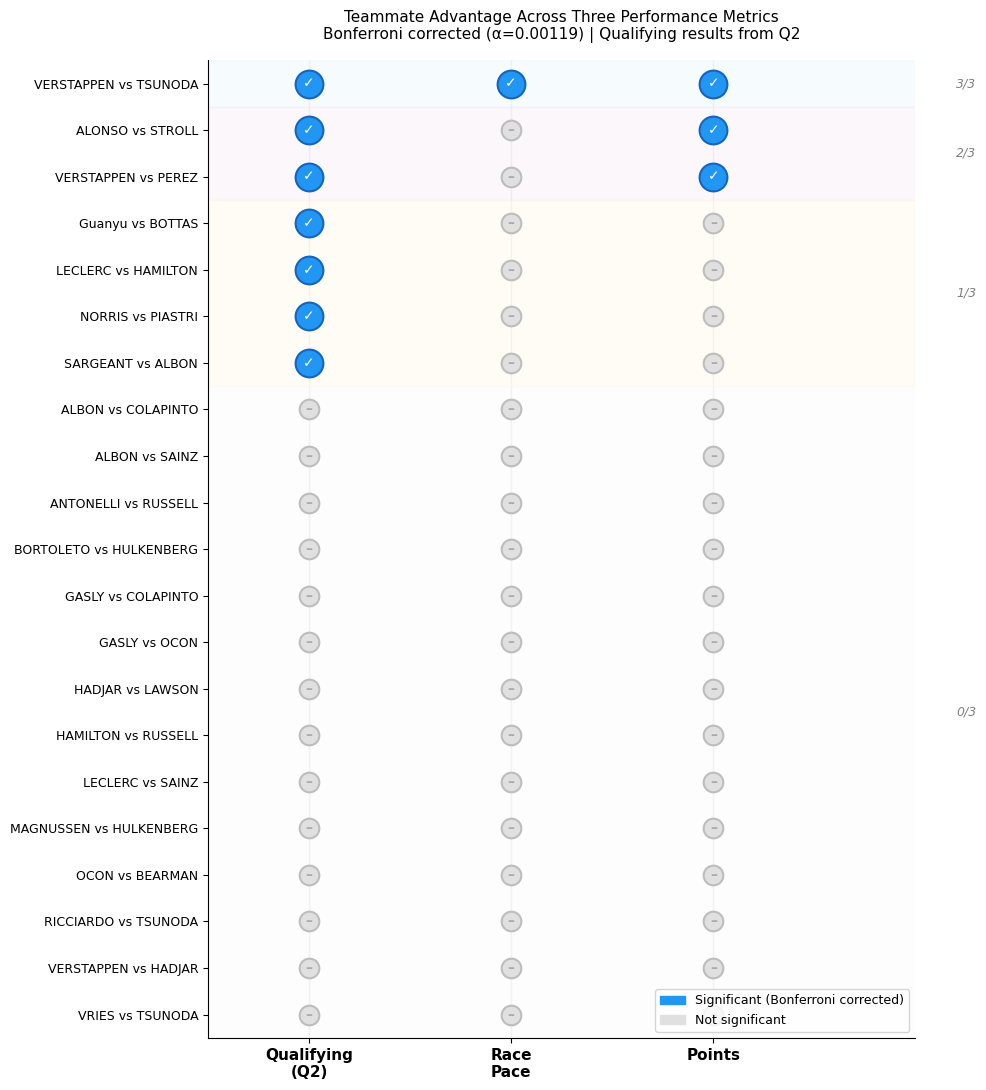

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# sort by n_sig_metrics
viz_data = df_results_test[['pair_id','driver_a','driver_b',
                             'quali_sig','pace_sig','points_sig',
                             'n_sig_metrics']].copy()
viz_data['pair_label'] = viz_data.apply(
    lambda r: f"{r['driver_a'].split()[-1]} vs {r['driver_b'].split()[-1]}", axis=1)
viz_data = viz_data.sort_values(['n_sig_metrics','pair_label'], 
                                 ascending=[False,True]).reset_index(drop=True)

metrics = ['Qualifying\n(Q2)', 'Race\nPace', 'Points']
sig_cols = ['quali_sig','pace_sig','points_sig']

fig, ax = plt.subplots(figsize=(10, 11))

for i, row in viz_data.iterrows():
    for j, col in enumerate(sig_cols):
        is_sig = row[col]
        color = '#2196F3' if is_sig else '#e0e0e0'
        size = 400 if is_sig else 200
        ax.scatter(j, i, s=size, color=color, zorder=3,
                  edgecolors='#1565C0' if is_sig else '#bdbdbd',
                  linewidth=1.5)
        # checkmark or cross
        ax.text(j, i, '✓' if is_sig else '–',
                ha='center', va='center', fontsize=10,
                color='white' if is_sig else '#aaaaaa',
                fontweight='bold')

# tier background shading
tier_colors = {3: '#e3f2fd', 2: '#f3e5f5', 1: '#fff8e1', 0: '#fafafa'}
tier_ranges = []
current_tier = viz_data.iloc[0]['n_sig_metrics']
start = 0
for i, row in viz_data.iterrows():
    if row['n_sig_metrics'] != current_tier or i == len(viz_data)-1:
        end = i if row['n_sig_metrics'] != current_tier else i+1
        tier_ranges.append((current_tier, start-0.5, end-0.5))
        current_tier = row['n_sig_metrics']
        start = i

for tier, y_start, y_end in tier_ranges:
    ax.axhspan(y_start, y_end, alpha=0.3, 
               color=tier_colors.get(tier,'white'), zorder=1)
    ax.text(3.2, (y_start+y_end)/2, f'{tier}/3', 
            va='center', fontsize=9, color='gray', style='italic')

# gridlines
for j in range(3):
    ax.axvline(j, color='#eeeeee', linewidth=1, zorder=0)

ax.set_xticks([0,1,2])
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(viz_data)))
ax.set_yticklabels(viz_data['pair_label'], fontsize=9)
ax.set_xlim(-0.5, 3.0)
ax.set_ylim(-0.5, len(viz_data)-0.5)
ax.invert_yaxis()

# legend
sig_patch = mpatches.Patch(color='#2196F3', label='Significant (Bonferroni corrected)')
ns_patch = mpatches.Patch(color='#e0e0e0', label='Not significant')
ax.legend(handles=[sig_patch, ns_patch], loc='lower right', fontsize=9)

ax.set_title('Teammate Advantage Across Three Performance Metrics\n'
             'Bonferroni corrected (α=0.00119) | Qualifying results from Q2',
             fontsize=11, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

- [X] Which factor  qualifying pace, race pace, reliability, or strategy execution  explains the most of the points gap between teammates? (regression decomposition)

METHOD:
Paired t-test per teammate pair per metric. One-sample t-test against zero 
on the delta series (driver_a - driver_b, where driver_number_a < 
driver_number_b for consistent sign). Minimum n=8 shared races. Bonferroni 
correction: α=0.05/(2 metrics × 21 pairs) = 0.00119. Qualifying results 
carried forward from Q2 (already Bonferroni corrected there).

Three metrics tested per pair:
  - Qualifying delta (from Q2): difference in qualifying lap time
  - Race pace delta: difference in session-normalized mean race lap time
  - Points delta: difference in points scored per race

21 valid pairs identified (n≥8 shared races). Results visualized as a 
dot matrix showing significance across three metrics per pair.

RESULTS BY TIER:

TIER 1 -- SIGNIFICANT ON ALL 3 METRICS (1 pair):
  Verstappen vs Tsunoda:
    Qualifying: significant (from Q2)
    Race pace: -1.10s/lap, p<0.001 (Verstappen faster)
    Points: +16.05/race, p<10^-8 (Verstappen scores 16 more points)
    The only pair with confirmed advantage across all three dimensions.
    Represents the largest statistically confirmed driver gap in the 
    dataset -- Tsunoda is a 2026 pairing with limited shared races but 
    the signal is overwhelming on every metric.

TIER 2 -- SIGNIFICANT ON 2 METRICS (2 pairs):
  Verstappen vs Perez:
    Qualifying: significant (from Q2)
    Race pace: -0.47s, p=0.025 (misses Bonferroni but directional)
    Points: +11.61/race, p<10^-9
    Well-documented F1 story confirmed statistically. Race pace just 
    misses correction threshold -- real effect, underpowered.

  Alonso vs Stroll:
    Qualifying: significant (from Q2)
    Race pace: -0.20s, p=0.164 (not significant)
    Points: +2.68/race, p=0.00006
    Alonso's advantage manifests in qualifying and points but NOT race 
    pace -- suggests his edge comes from strategic execution and 
    qualifying skill rather than raw race speed.

TIER 3 -- SIGNIFICANT ON 1 METRIC ONLY (4 pairs):
  All four significant only on qualifying:
  - Sargeant vs Albon: qualifying only
  - Leclerc vs Hamilton: qualifying only (brand new 2026 pairing, n=30)
  - Norris vs Piastri: qualifying only (race pace p=0.003, just misses)
  - Zhou vs Bottas: qualifying only

  These pairs show real qualifying advantages that are too noisy to 
  confirm in race pace or points -- consistent with qualifying being a 
  cleaner signal (one lap, controlled conditions) vs race outcomes 
  (strategy, SC, luck all add variance).

TIER 4 -- NO SIGNIFICANT ADVANTAGE ON ANY METRIC (14 pairs):
  Genuinely competitive pairings or insufficient shared races. Includes:
  Hamilton vs Russell, Leclerc vs Sainz, Magnussen vs Hulkenberg, 
  all RB Family pairings, all Alpine pairings.

KEY FINDINGS:
1. Qualifying is the easiest metric to show significance -- single lap, 
   controlled conditions, minimal noise. Most confirmed advantages show 
   up here first.
2. Race pace advantages are harder to confirm -- strategy, SC, and race 
   circumstances add enormous lap-to-lap variance.
3. Points advantages are significant only when the underlying skill gap 
   is large (Verstappen cases) or consistent over many races (Alonso).
4. Most teammate pairings (14/21) show NO statistically confirmed 
   advantage on any metric -- F1 teams pair drivers of similar ability, 
   and race-to-race noise dominates for most pairings.

BONFERRONI NOTE:
Norris vs Piastri race pace (p=0.003) just misses the strict Bonferroni 
threshold (α=0.00119). This is genuinely borderline -- a real but small 
advantage that would survive less conservative corrections (FDR/BH). 
Treat as "suggestive but not confirmed."

- [X] Which factor  qualifying pace, race pace, reliability, or strategy execution  explains the most of the points gap between teammates? (regression decomposition)

In [32]:
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from data_prep import normalize_team_names


results_query = """
SELECT sr.session_key, sr.driver_number,
       sr.points, sr.dnf,
       d.team_name, s.year
FROM silver_session_result sr
JOIN silver_sessions s ON sr.session_key = s.session_key 
    AND s.session_name = 'Race'
JOIN silver_drivers d ON sr.session_key = d.session_key 
    AND sr.driver_number = d.driver_number
WHERE sr.dns = 0
  AND sr.points IS NOT NULL
"""
df_results = pd.read_sql(results_query, conn)
df_results = normalize_team_names(df_results)
df_results = df_results[df_results['team_name'] != 'Cadillac'].copy()

print(df_results.shape)

(1460, 6)


In [33]:
pace_query = """
SELECT l.session_key, l.driver_number,
       AVG(l.lap_duration) AS mean_lap
FROM silver_laps l
JOIN silver_sessions s ON l.session_key = s.session_key 
    AND s.session_name = 'Race'
WHERE l.lap_duration IS NOT NULL
  AND l.lap_duration BETWEEN 60 AND 200
  AND l.is_pit_out_lap = 0
GROUP BY l.session_key, l.driver_number
HAVING COUNT(*) >= 25
"""
df_pace = pd.read_sql(pace_query, conn)

session_medians = df_pace.groupby('session_key')['mean_lap'].median().reset_index()
session_medians.columns = ['session_key','session_median']
df_pace = df_pace.merge(session_medians, on='session_key')
df_pace['pace_vs_median'] = df_pace['mean_lap'] - df_pace['session_median']

print(df_pace.shape)

(1366, 5)


In [34]:
quali_query = """
SELECT g.driver_number, g.lap_duration AS quali_lap, gs.meeting_key,
       (SELECT rs.session_key FROM silver_sessions rs 
        WHERE rs.meeting_key = gs.meeting_key 
        AND rs.session_name = 'Race' LIMIT 1) AS session_key
FROM silver_starting_grid g
JOIN silver_sessions gs ON g.session_key = gs.session_key
WHERE gs.session_name = 'Qualifying'
  AND g.lap_duration IS NOT NULL
"""
df_quali = pd.read_sql(quali_query, conn)

print(df_quali.shape)

(1385, 4)


In [35]:
pit_query = """
SELECT p.session_key, p.driver_number,
       COUNT(*) AS pit_count
FROM silver_pit p
JOIN silver_sessions s ON p.session_key = s.session_key 
    AND s.session_name = 'Race'
GROUP BY p.session_key, p.driver_number
"""
df_pits = pd.read_sql(pit_query, conn)

print(df_pits.shape)
print(df_pits['pit_count'].value_counts().sort_index())

(1278, 3)
pit_count
1    511
2    556
3    111
4     46
5     39
6     11
7      4
Name: count, dtype: int64


In [36]:
# merge all predictors onto results
df_master = df_results.merge(
    df_pace[['session_key','driver_number','pace_vs_median']],
    on=['session_key','driver_number'], how='left'
)
df_master = df_master.merge(
    df_quali[['session_key','driver_number','quali_lap']],
    on=['session_key','driver_number'], how='left'
)
df_master = df_master.merge(
    df_pits, on=['session_key','driver_number'], how='left'
)

print(df_master.shape)
print(df_master.isna().sum())

(1460, 9)
session_key         0
driver_number       0
points              0
dnf                 0
team_name           0
year                0
pace_vs_median    182
quali_lap         161
pit_count         254
dtype: int64


In [37]:
# self-join on same team same race
df_pairs = df_master.merge(
    df_master,
    on=['session_key','team_name','year'],
    suffixes=('_a','_b')
)

# consistent ordering
df_pairs = df_pairs[df_pairs['driver_number_a'] < df_pairs['driver_number_b']].copy()

# compute deltas (a - b)
df_pairs['points_delta'] = df_pairs['points_a'] - df_pairs['points_b']
df_pairs['pace_delta'] = df_pairs['pace_vs_median_a'] - df_pairs['pace_vs_median_b']
df_pairs['quali_delta'] = df_pairs['quali_lap_a'] - df_pairs['quali_lap_b']
df_pairs['reliability_delta'] = df_pairs['dnf_a'] - df_pairs['dnf_b']
df_pairs['pit_delta'] = df_pairs['pit_count_a'] - df_pairs['pit_count_b']

print(df_pairs.shape)
print(df_pairs[['points_delta','pace_delta','quali_delta',
                'reliability_delta','pit_delta']].describe())

(721, 20)
       points_delta  pace_delta  quali_delta  reliability_delta   pit_delta
count    721.000000  594.000000   625.000000         721.000000  569.000000
mean       1.682386   -0.107876    -0.009746          -0.008322   -0.003515
std        7.485937    0.873206     3.495369           0.450232    0.837073
min      -25.000000   -5.581534   -62.297000          -1.000000   -4.000000
25%        0.000000   -0.447983    -0.474000           0.000000    0.000000
50%        0.000000   -0.076315    -0.056000           0.000000    0.000000
75%        4.000000    0.302362     0.319000           0.000000    0.000000
max       26.000000    4.731723    38.516000           1.000000    5.000000


In [38]:
print("Quali delta distribution:")
print((df_pairs['quali_delta'].abs() > 5).sum(), "rows with |quali_delta| > 5s")
print((df_pairs['quali_delta'].abs() > 2).sum(), "rows with |quali_delta| > 2s")

df_pairs_clean = df_pairs.dropna(subset=['points_delta','pace_delta',
                                          'quali_delta','reliability_delta',
                                          'pit_delta']).copy()
df_pairs_clean = df_pairs_clean[df_pairs_clean['quali_delta'].abs() <= 5].copy()

print(f"\nClean pairs: {df_pairs_clean.shape[0]}")
df_pairs_clean[['points_delta','pace_delta','quali_delta',
                'reliability_delta','pit_delta']].describe().round(3)

Quali delta distribution:
22 rows with |quali_delta| > 5s
43 rows with |quali_delta| > 2s

Clean pairs: 461


,points_delta,pace_delta,quali_delta,reliability_delta,pit_delta
count,461.000,461.000,461.000,461.000,461.000
mean,1.655,-0.113,-0.099,-0.011,0.022
std,7.214,0.824,0.816,0.319,0.802
min,-18.000,-5.582,-4.881,-1.000,-3.000
25%,-1.000,-0.442,-0.456,0.000,0.000
50%,0.000,-0.094,-0.053,0.000,0.000
75%,4.000,0.254,0.284,0.000,0.000
max,26.000,3.932,4.899,1.000,5.000


In [39]:
model = smf.ols(
    'points_delta ~ pace_delta + quali_delta + reliability_delta + pit_delta',
    data=df_pairs_clean
).fit()
print(model.summary())

# standardized coefficients for relative importance comparison
scaler = StandardScaler()
df_std = df_pairs_clean[['points_delta','pace_delta','quali_delta',
                          'reliability_delta','pit_delta']].copy()
df_std[['pace_delta','quali_delta','reliability_delta','pit_delta']] = \
    scaler.fit_transform(df_std[['pace_delta','quali_delta',
                                  'reliability_delta','pit_delta']])

model_std = smf.ols(
    'points_delta ~ pace_delta + quali_delta + reliability_delta + pit_delta',
    data=df_std
).fit()
print("\nStandardized coefficients (relative importance):")
print(model_std.params.round(3))

                            OLS Regression Results                            
Dep. Variable:           points_delta   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     31.48
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           3.63e-23
Time:                        11:22:05   Log-Likelihood:                -1508.4
No. Observations:                 461   AIC:                             3027.
Df Residuals:                     456   BIC:                             3047.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.1374      0.30

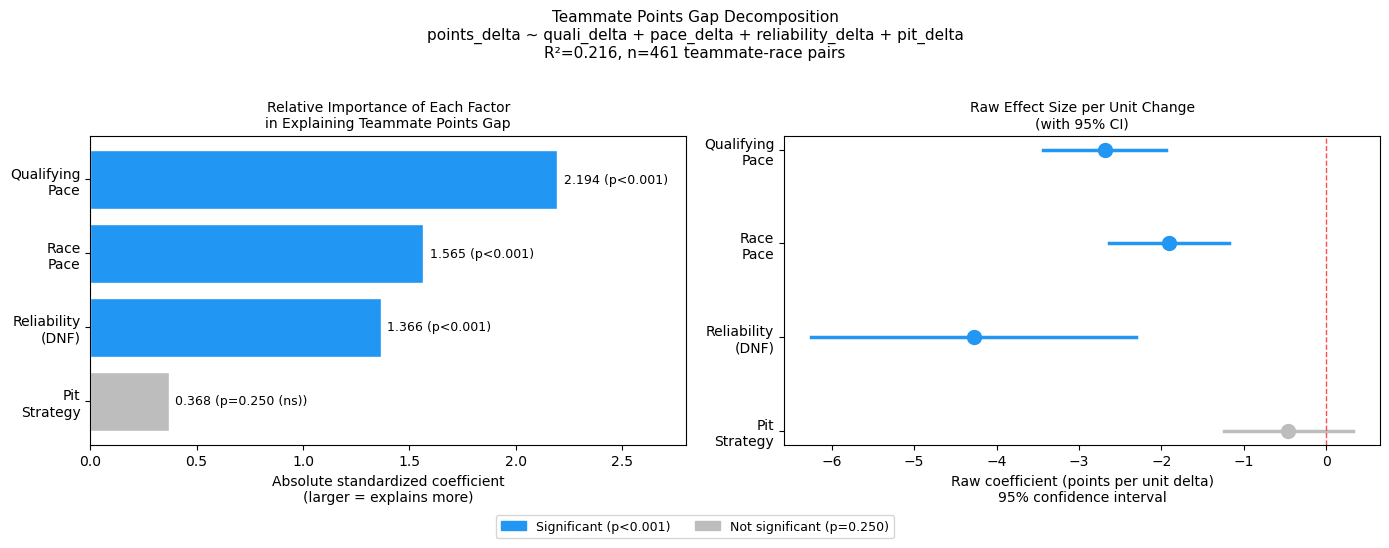

In [40]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: standardized coefficients (relative importance)
predictors = ['Qualifying\nPace', 'Race\nPace', 'Reliability\n(DNF)', 'Pit\nStrategy']
std_coefs = [-2.194, -1.565, -1.366, -0.368]
colors = ['#2196F3' if p < 0.05 else '#bdbdbd' 
          for p in [0.000, 0.000, 0.000, 0.250]]
sig_labels = ['p<0.001', 'p<0.001', 'p<0.001', 'p=0.250 (ns)']

bars = axes[0].barh(predictors, [abs(c) for c in std_coefs],
                    color=colors, edgecolor='white')
axes[0].set_xlabel('Absolute standardized coefficient\n(larger = explains more)', fontsize=10)
axes[0].set_title('Relative Importance of Each Factor\nin Explaining Teammate Points Gap',
                   fontsize=10)
axes[0].axvline(x=0, color='black', linewidth=0.5)
for bar, coef, sig in zip(bars, std_coefs, sig_labels):
    axes[0].text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
                f'{abs(coef):.3f} ({sig})',
                va='center', fontsize=9)
axes[0].set_xlim(0, 2.8)
axes[0].invert_yaxis()

# Right: raw coefficients with confidence intervals
raw_coefs = [-2.690, -1.903, -4.280, -0.460]
ci_low = [-3.431, -2.632, -6.251, -1.245]
ci_high = [-1.949, -1.173, -2.308, 0.325]
y_pos = [0, 1, 2, 3]

for i, (coef, low, high, pred, sig) in enumerate(zip(
        raw_coefs, ci_low, ci_high, predictors, sig_labels)):
    color = '#2196F3' if 'ns' not in sig else '#bdbdbd'
    axes[1].plot([low, high], [i, i], color=color, linewidth=2.5, zorder=2)
    axes[1].scatter(coef, i, color=color, s=100, zorder=3)

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(predictors, fontsize=10)
axes[1].set_xlabel('Raw coefficient (points per unit delta)\n95% confidence interval', fontsize=10)
axes[1].set_title('Raw Effect Size per Unit Change\n(with 95% CI)',fontsize=10)
axes[1].invert_yaxis()

# legend
from matplotlib.patches import Patch
sig_patch = Patch(color='#2196F3', label='Significant (p<0.001)')
ns_patch = Patch(color='#bdbdbd', label='Not significant (p=0.250)')
fig.legend(handles=[sig_patch, ns_patch], loc='lower center',
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Teammate Points Gap Decomposition\n'
             'points_delta ~ quali_delta + pace_delta + '
             'reliability_delta + pit_delta\n'
             f'R²=0.216, n=461 teammate-race pairs',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


METHOD:
Unit of analysis: one row per (race, teammate pair). Outcome: points_delta 
= driver_a points - driver_b points per race (driver_number_a < 
driver_number_b for consistent sign). n=461 clean teammate-race pairs after:
  - Dropping NaN on any predictor (pace, quali, pit coverage gaps)
  - Filtering |quali_delta| > 5s (22 rows removed as physically implausible 
    -- likely Sprint/Race session mismatches in silver_starting_grid)

Four predictors (all as driver_a minus driver_b deltas):
  quali_delta:         qualifying lap time difference (seconds)
  pace_delta:          session-normalized mean race pace difference (seconds)
  reliability_delta:   DNF flag difference (−1/0/+1)
  pit_delta:           pit stop count difference (strategy proxy)

Standardized coefficients computed for relative importance comparison -- 
puts all predictors on same scale (mean=0, std=1) so coefficients are 
directly comparable regardless of original units.

MODEL RESULTS:
  R²=0.216, F=31.48, p<10^-23, n=461

  Raw coefficients:
    Intercept:          +1.137 (p<0.001)
    quali_delta:        -2.690 (p<0.001)
    pace_delta:         -1.903 (p<0.001)
    reliability_delta:  -4.280 (p<0.001)
    pit_delta:          -0.460 (p=0.250) -- NOT significant

  All negative signs are correct per convention: when driver_a has a 
  negative delta (faster/more reliable), they score more points 
  (negative points_delta = driver_a ahead).

RELATIVE IMPORTANCE (standardized coefficients, absolute values):
  1. Qualifying pace:   2.194 -- STRONGEST
  2. Race pace:         1.565 -- second
  3. Reliability (DNF): 1.366 -- third
  4. Pit strategy:      0.368 -- NOT significant

DIRECT ANSWER:
Qualifying pace explains the MOST of the teammate points gap, followed 
by race pace, then reliability. Pit strategy (pit count delta) adds no 
significant explanatory power once the other three are controlled for.

WHY QUALIFYING OUTRANKS RACE PACE:
Counterintuitive but mechanistically defensible:
  1. TRACK POSITION COMPOUNDS: starting ahead = cleaner air, better pit 
     windows, less need to overtake (only 16.7% conversion rate per 
     event-level analysis). A qualifying advantage translates to 
     compounding race advantages lap by lap.
  2. STRATEGIC PRIORITY: teams typically give the better qualifier 
     priority on strategy calls (first pit window, preferred tyre 
     allocation). Qualifying advantage → strategic advantage → points.
  3. MEASUREMENT QUALITY: qualifying is a clean single-lap signal; race 
     pace is measured across 50+ laps with SC, traffic, tyre management 
     noise. Qualifying delta is a more stable predictor because it has 
     less measurement error.

RAW RELIABILITY COEFFICIENT (-4.28) VS STANDARDIZED (1.366):
The large raw coefficient (-4.28 points per DNF difference) reflects 
that a single DNF creates an immediate ~4-15 point swing vs your 
teammate. But reliability_delta has very low variance (mostly 0 -- both 
drivers finish most races), so its standardized coefficient is lower 
than qualifying or race pace despite the large per-event impact. 
Reliability matters enormously WHEN it happens; it just doesn't happen 
often enough to dominate the season-level explanation.

PIT STRATEGY NON-SIGNIFICANCE (p=0.250):
Consistent with championship decomposition finding (Q last): pit count 
delta adds no independent explanatory power once pace and reliability 
are controlled for. At driver level as at team level, strategy execution 
is too correlated with other factors to contribute independently. The 
one-stop vs two-stop finding from earlier questions (fewer stops = 
better outcome) holds in aggregate but not at the individual teammate-
race level after controlling for pace.

COMPARISON WITH CHAMPIONSHIP DECOMPOSITION FINDING:
Championship decomposition (team level, season points):
  Pace dominated, reliability non-significant (p=0.967)

This question (driver level, race points gap):
  Qualifying pace dominates, race pace second, reliability third 
  (p<0.001), pit strategy non-significant

Key difference: reliability becomes significant at driver level but not 
team level. Why? At team level, DNFs partially cancel -- when one driver 
DNFs, the other often scores, partially offsetting the reliability cost. 
At driver level (teammate comparison), a DNF creates an immediate, large 
same-race points gap between the two drivers that can't be cancelled. 
This is exactly the mechanism we predicted in the design phase.

R²=0.216 -- WHAT THE REMAINING 78.4% IS:
The unexplained variance reflects genuine race randomness not captured 
by these four predictors:
  - Safety Car timing (who benefits vs who gets caught out)
  - First-lap incidents independent of driver skill
  - Mechanical failures not captured by DNF flag (slow laps, limping)
  - Weather transitions (wet/dry timing advantages)
  - Opponent behavior (backmarkers, traffic)
  - Field density at specific race moments

TAKEAWAY FOR PREDICTIVE MODEL (Phase 3):
At the driver level, the ranking is: qualifying pace > race pace > 
reliability > strategy. Qualifying pace is the single most valuable 
feature for predicting which teammate will score more points. This 
connects directly to the constructor-win prediction model:
  - Team qualifying performance (both cars' grid positions) should be 
    a primary feature
  - Session-normalized race pace (already identified at team level) 
    remains important
  - Reliability (DNF rate, from team-level analysis) adds value at 
    driver level but less at team level
  - Strategy metrics (pit count, stop duration) should be excluded 
    from the model to avoid multicollinearity without adding signal

VISUALIZATION:
Left panel (standardized coefficients): qualifying pace bar longest -- 
confirms it explains the most. Pit strategy gray (not significant).
Right panel (raw coefficients with 95% CIs): reliability has the 
largest raw effect per unit but widest CI (rare event, high variance). 
Qualifying and race pace CIs are tighter and don't cross zero. Pit 
strategy CI crosses zero -- confirms non-significance.